In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter

In [6]:
dataset = load_dataset("mteb/banking77")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 9993
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 3076
    })
})


In [7]:
print("\n--- Column names ---")
print(dataset["train"].column_names)


--- Column names ---
['text', 'label', 'label_text']


In [8]:
print("\n--- First 3 examples ---")
for i in range(3):
    print(f"\n[{i}] {dataset['train'][i]}")


--- First 3 examples ---

[0] {'text': 'I am still waiting on my card?', 'label': 11, 'label_text': 'card_arrival'}

[1] {'text': "What can I do if my card still hasn't arrived after 2 weeks?", 'label': 11, 'label_text': 'card_arrival'}

[2] {'text': 'I have been waiting over a week. Is the card still coming?', 'label': 11, 'label_text': 'card_arrival'}


In [11]:
counts = Counter(dataset["train"]["label_text"])
labels = sorted(counts.keys())

In [12]:
print(f"Number of classes: {len(counts)}")
print(f"Total train samples: {len(dataset['train'])}")
print(f"Total test samples: {len(dataset['test'])}")
print(f"Samples per class (roughly): {len(dataset['train']) // len(counts)}")

Number of classes: 77
Total train samples: 9993
Total test samples: 3076
Samples per class (roughly): 129


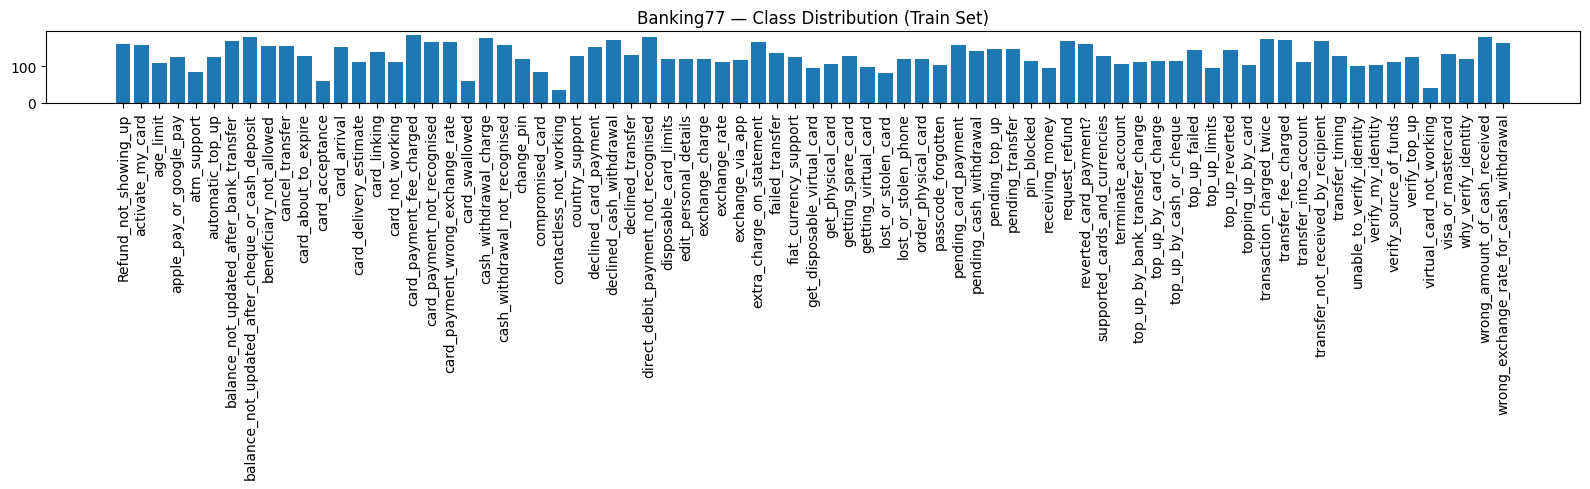

In [13]:
values = [counts[l] for l in labels]

plt.figure(figsize=(16, 5))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.title("Banking77 — Class Distribution (Train Set)")
plt.tight_layout()
plt.savefig("../assets/class_distribution.png")
plt.show()

In [14]:
print("=== SAMPLE TEXTS BY CLASS ===\n")
seen = set()
for ex in dataset["train"]:
    if ex["label_text"] not in seen:
        print(f"[{ex['label_text']}]")
        print(f"  \"{ex['text']}\"\n")
        seen.add(ex["label_text"])
    if len(seen) == 10:
        break

=== SAMPLE TEXTS BY CLASS ===

[card_arrival]
  "I am still waiting on my card?"

[card_linking]
  "My card has been found. Is there any way for me to put it back into the app?"

[exchange_rate]
  "What is my money worth in other countries?"

[card_payment_wrong_exchange_rate]
  "Last Saturday, I was charged extra for the exchange rate on my payment. Is something wrong?"

[extra_charge_on_statement]
  "Why is there an extra fee on my statement?"

[pending_cash_withdrawal]
  "I would like to know why a withdraw I made for some cash shows up as pending."

[fiat_currency_support]
  "How many different currencies can I hold money in?"

[card_delivery_estimate]
  "Can it specifically be delivered on a certain date?"

[automatic_top_up]
  "Can I add money automatically to my account while traveling?"

[card_not_working]
  "I can't use my card because it is not working."

